In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from cycler import cycler

In [2]:
import pandas as pd

data = pd.read_csv("Steam_Games.csv",)

In [3]:
data.shape

(111452, 40)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111452 entries, 0 to 111451
Data columns (total 40 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       111452 non-null  int64  
 1   Name                        111446 non-null  object 
 2   Release date                111452 non-null  object 
 3   Estimated owners            111452 non-null  object 
 4   Peak CCU                    111452 non-null  int64  
 5   Required age                111452 non-null  int64  
 6   Price                       111452 non-null  float64
 7   Discount                    111452 non-null  int64  
 8   DLC count                   111452 non-null  int64  
 9   About the game              104969 non-null  object 
 10  Supported languages         111452 non-null  object 
 11  Full audio languages        111452 non-null  object 
 12  Reviews                     10624 non-null   object 
 13  Header image  

In [5]:
data = data.drop(columns=["Screenshots",
                          "Movies",
                          "Notes",
                          "Metacritic url",
                          "Website",
                          "Support url",
                          "Support email",
                          "Peak CCU"
                         ])

In [6]:
data.sample(3)

,AppID,Name,Release date,Estimated owners,Required age,Price,Discount,DLC count,About the game,Supported languages,...,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags
109425,3485070,Pompeii: The Legacy Playtest,"Mar 18, 2025",0 - 0,0,0.00,0,0,NaN,[],...,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN
101764,3158110,Dino Age: Dinosaur Survival Game,"Oct 30, 2024",0 - 20000,0,5.99,0,0,"In the dawn of the 21st century, you take on t...",['English'],...,0,0,0,0,0,Dino Age,Dino Age,"Single-player,Family Sharing","Action,Adventure,Indie,RPG",NaN
99423,3134540,UFO,"Sep 26, 2024",20000 - 50000,0,0.99,0,1,UFO is a short stream-of-consciousness visual ...,"['English', 'Japanese', 'Simplified Chinese', ...",...,0,0,0,0,0,jiangli,gooodmon,"Single-player,Steam Achievements,Family Sharing",Indie,"Casual,RPG,Interactive Fiction,Dating Sim,Poin..."


In [7]:
data.isnull()

,AppID,Name,Release date,Estimated owners,Required age,Price,Discount,DLC count,About the game,Supported languages,...,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111447,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
111448,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
111449,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
111450,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [8]:
data = data[
    data["Name"].apply(
        lambda x: str(x).isascii()
    )
]

# ANALYSIS OF MOST POPULAR CATEGORIES

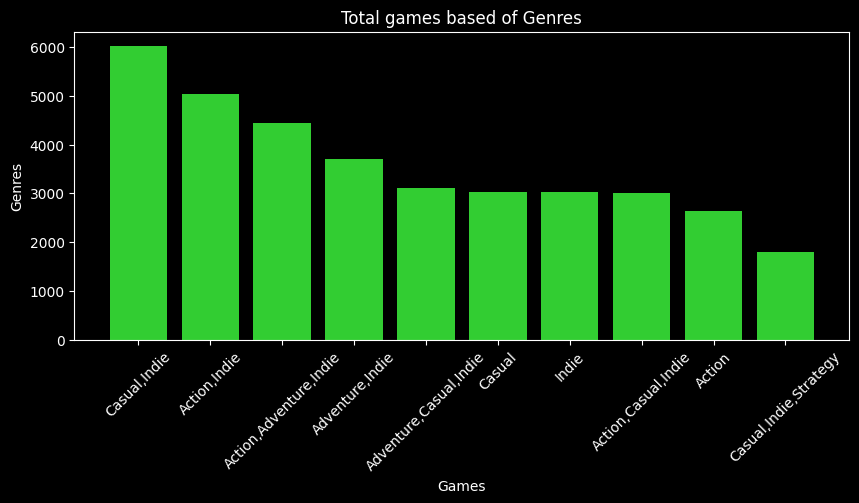

In [9]:
# Genres of games on steam
plt.style.use("dark_background")
genre_counts = data["Genres"].value_counts().head(10)

plt.figure(figsize=(10,4))
plt.bar(genre_counts.index,
       genre_counts.values,
       color="limegreen")

plt.title("Total games based of Genres")
plt.xlabel("Games")
plt.xticks(rotation=45)
plt.ylabel("Genres")
plt.show()

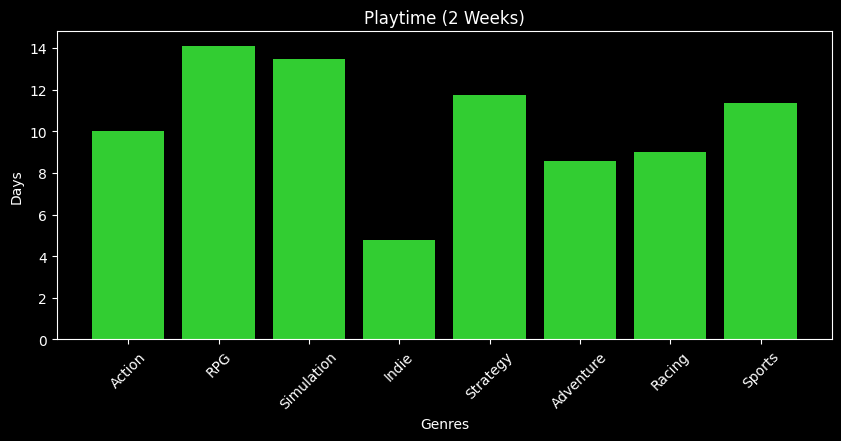

In [10]:
# Most played games (Two Weeks) according to Genres
plt.style.use("dark_background")

genres=["Action","RPG","Simulation","Indie","Strategy","Adventure","Racing","Sports"]

plt.figure(figsize=(10,4))

avg=[]

for g in genres:

    temp=data[data["Genres"].str.contains(g,na=False)]

    avg.append(temp["Average playtime two weeks"].mean())

plt.bar(genres,avg,color="limegreen",)
plt.title("Playtime (2 Weeks)")
plt.xlabel("Genres")
plt.xticks(rotation=45)
plt.ylabel("Days")

plt.show()

In [11]:
data["Genres"].unique()

array(['Casual,Indie,Sports', 'Action,Indie',
       'Action,Adventure,Indie,Strategy', ...,
       'Action,Racing,Free To Play,Early Access',
       'Action,Casual,Indie,Massively Multiplayer,RPG,Strategy',
       'Indie,Massively Multiplayer,Strategy,Free To Play'],
      shape=(3009,), dtype=object)

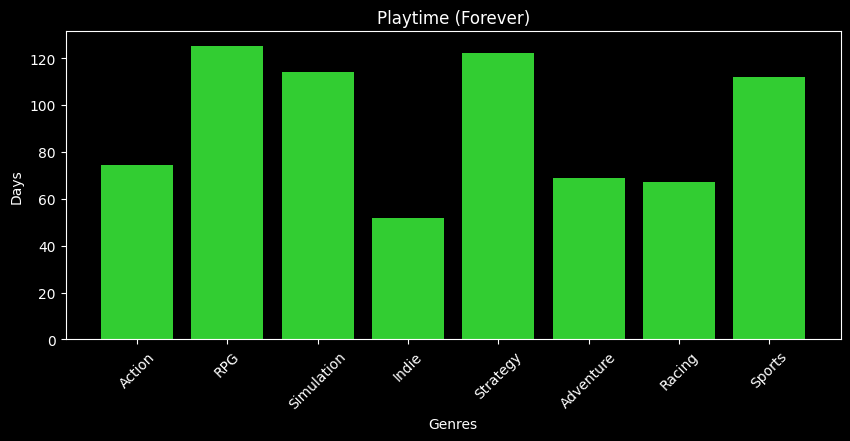

In [12]:
# Most played games (of altime) according to Genres
plt.style.use("dark_background")

genres=["Action","RPG","Simulation","Indie","Strategy","Adventure","Racing","Sports"]

plt.figure(figsize=(10,4))

avg=[]

for g in genres:

    temp=data[data["Genres"].str.contains(g,na=False)]

    avg.append(temp["Average playtime forever"].mean())

plt.bar(genres,avg,color="limegreen")
plt.title("Playtime (Forever)")
plt.xlabel("Genres")
plt.xticks(rotation=45)
plt.ylabel("Days")

plt.show()

# COMPARING GAMES

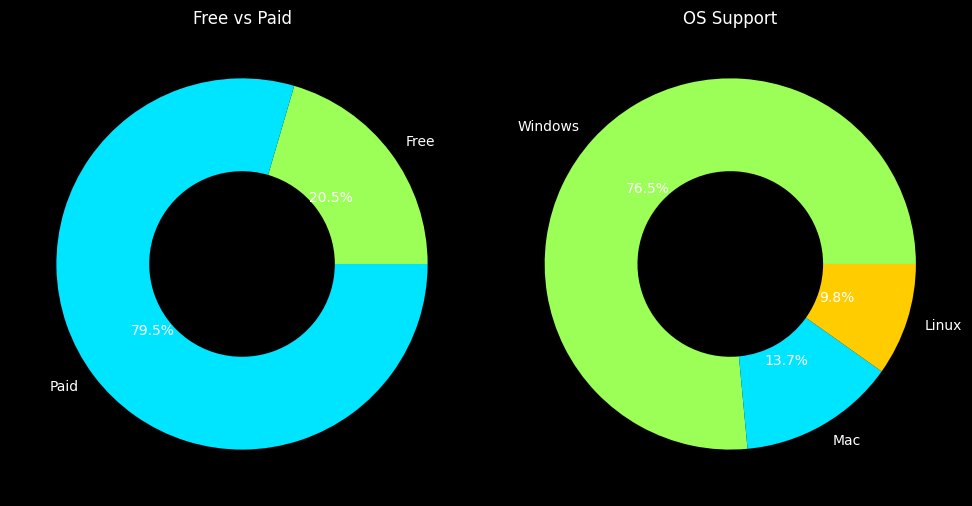

In [13]:
plt.style.use("dark_background")

plt.rcParams["axes.prop_cycle"]=cycler(color=[
"#9cff57", 
"#00e5ff",
"#ffcc00",
"#ff4d6d",
"#9b5cff",
"#00ff95",
"#ff8c42"
])


free = (data["Price"] == 0).sum()
paid = (data["Price"] > 0).sum()


windows = data["Windows"].sum()
mac = data["Mac"].sum()
linux = data["Linux"].sum()
os_counts = [windows,mac,linux]
os_labels = ["Windows","Mac","Linux"]

plt.figure(figsize=(10,5))


# Free vs Paid

plt.subplot(1,2,1)

plt.pie([free,paid],labels=["Free","Paid"],autopct="%1.1f%%",wedgeprops={"width":0.5})

plt.title("Free vs Paid")

# OS Support

plt.subplot(1,2,2)

plt.pie(os_counts,labels=os_labels,autopct="%1.1f%%",wedgeprops={"width":0.5})

plt.title("OS Support")
plt.tight_layout()
plt.show()

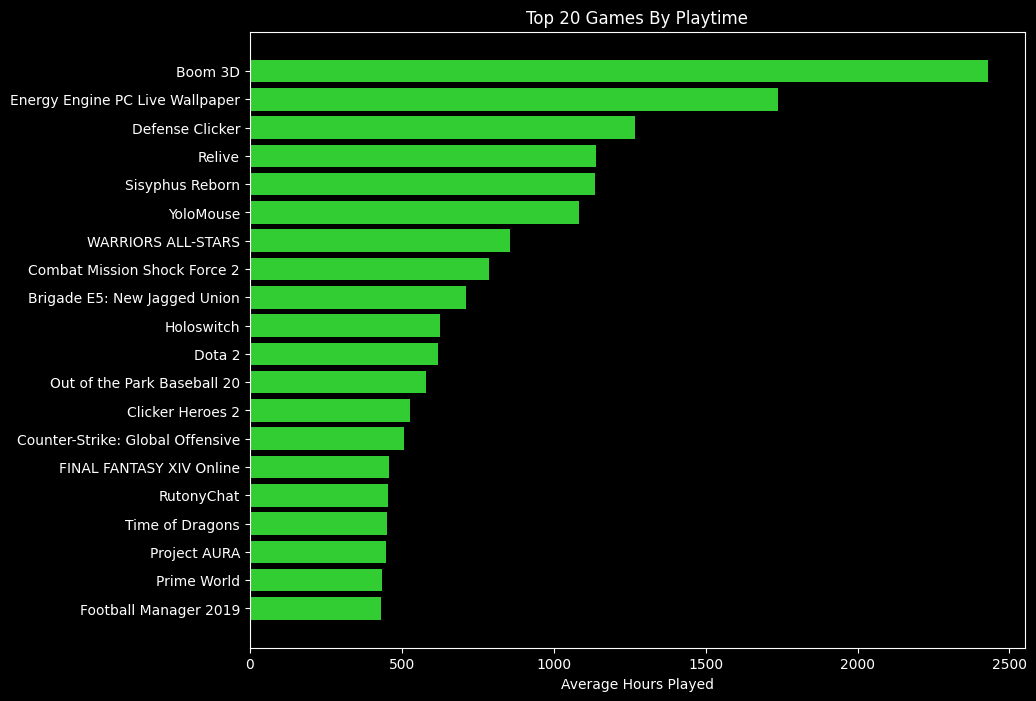

In [14]:
# Top 20 games by playtime
top20 = data.nlargest(20,"Average playtime forever")

top20["Hours Played"] = (top20["Average playtime forever"] / 60).round(1)

plt.figure(figsize=(10,8))
plt.barh(top20["Name"],top20["Hours Played"],color="limegreen",)
plt.xlabel("Average Hours Played")
plt.title("Top 20 Games By Playtime")

plt.gca().invert_yaxis()

plt.show()

# REVIEW ANALYSIS

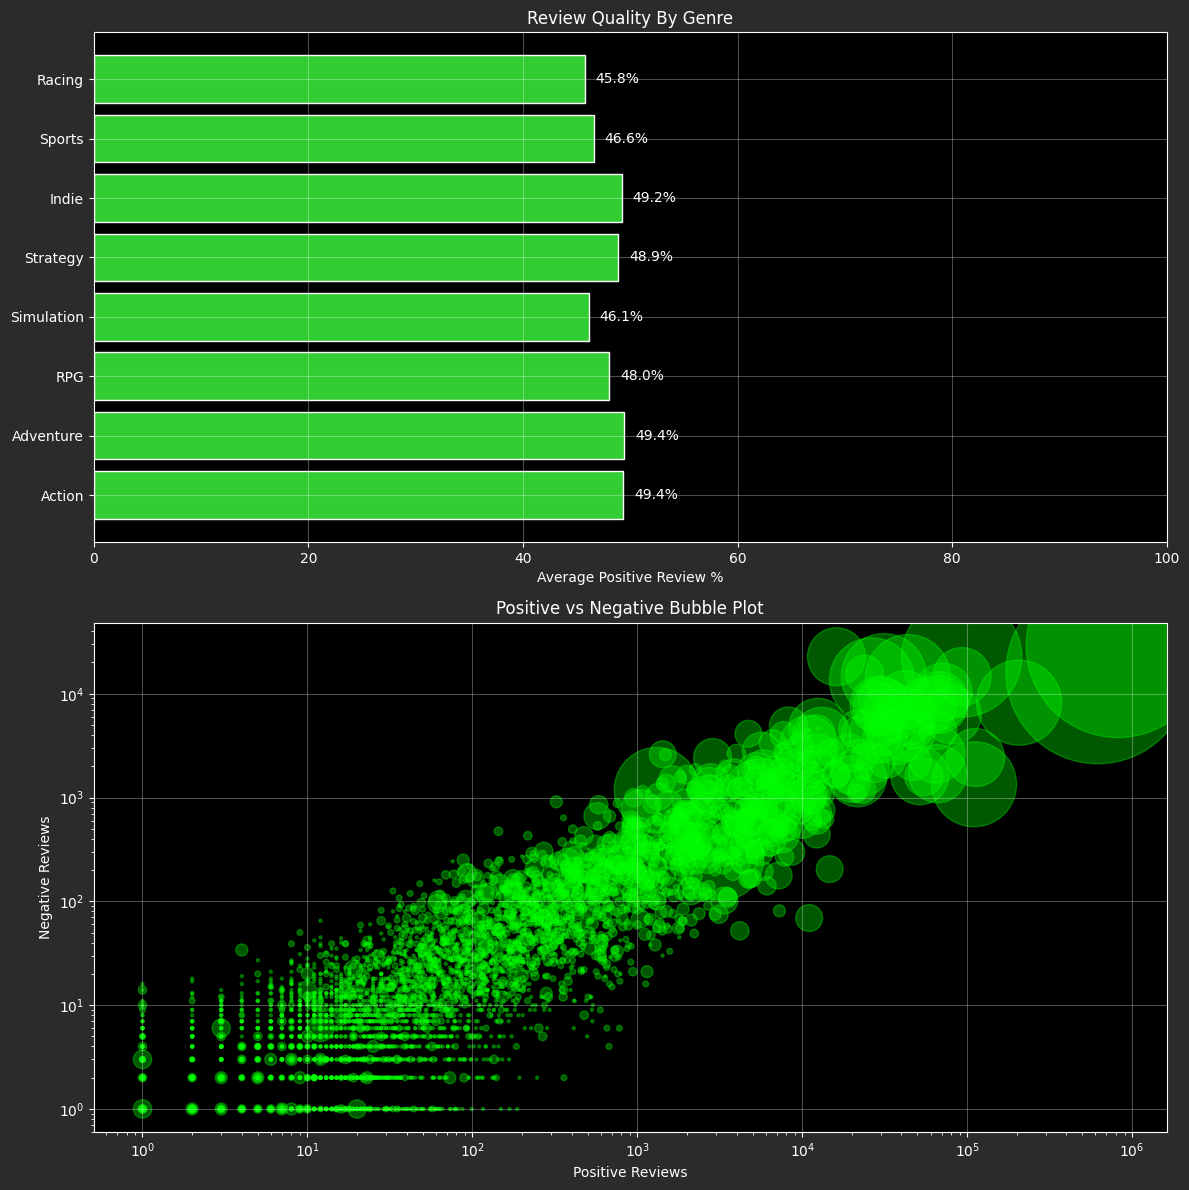

In [15]:
plt.style.use("dark_background")

GENRES=[
"Action","Adventure","RPG",
"Simulation","Strategy",
"Indie","Sports","Racing"
]


# Convert owner ranges

data["Estimated owners"]=data[
"Estimated owners"
].apply(

lambda x:

(sum(map(int,str(x).split("-")))/2)

if "-" in str(x)

else np.nan

)


# Convert columns to numeric

cols=[
"Positive",
"Negative",
"Estimated owners"
]

for c in cols:

    data[c]=pd.to_numeric(
        data[c],
        errors="coerce"
    )


review_rate=[]

for g in GENRES:

    sub=data[
    data["Genres"].str.contains(
    g,
    na=False
    )
    ].copy()

    sub["ratio"]=(

    sub["Positive"]

    /

    (

    sub["Positive"]

    +

    sub["Negative"]

    +

    1

    )

    )*100

    review_rate.append(
    sub["ratio"].mean()
    )


sample=data[

(data["Positive"]>0)

&

(data["Negative"]>0)

&

(data["Estimated owners"]>0)

].sample(
5000,
random_state=42
)


plt.figure(
figsize=(12,12),
facecolor="#2b2b2b"
)


# Plot 1

plt.subplot(2,1,1)
bars=plt.barh(

GENRES,

review_rate,

color="limegreen",

edgecolor="white"

)

for bar,val in zip(
bars,
review_rate
):

    plt.text(

    val+1,

    bar.get_y()+bar.get_height()/2,

    f"{val:.1f}%",

    va="center"

    )

plt.xlabel("Average Positive Review %")

plt.title("Review Quality By Genre")

plt.xlim(0,100)

plt.grid(alpha=.3)



# Plot 2

plt.subplot(2,1,2)
plt.scatter(

sample["Positive"],

sample["Negative"],

s=sample["Estimated owners"]/2000,alpha=.35,c="lime")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Positive Reviews")
plt.ylabel("Negative Reviews")
plt.title("Positive vs Negative Bubble Plot")
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()

# PRICE ANALYSIS

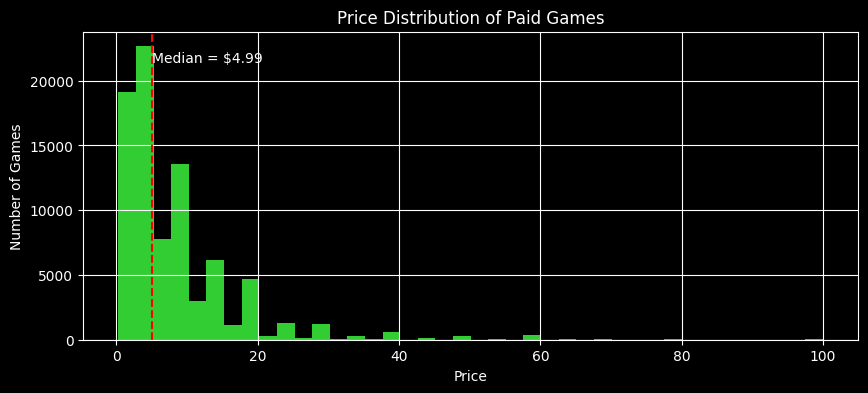

In [16]:
plt.figure(figsize=(10,4))

paid = data[data["Price"] > 0]

paid = paid[paid["Price"] <= 100]

plt.hist(paid["Price"],bins=40,color="limegreen")

median = paid["Price"].median()

plt.axvline(median,color="red",linestyle="--")

plt.text(median,plt.ylim()[1]*0.9,f"Median = ${median:.2f}")

plt.xlabel("Price")

plt.ylabel("Number of Games")

plt.title("Price Distribution of Paid Games")

plt.grid()
plt.show()